In [28]:
# !pip install optuna

In [29]:
import time
import copy
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna

os.makedirs("figs", exist_ok=True)
os.makedirs("model", exist_ok=True)
os.makedirs("data", exist_ok=True)

import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Data Loading

In [30]:
DATA_PATH = "data/train.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}.\n\n"
        "This notebook expects train.csv (and test.csv / sampleSubmission.csv) "
        "inside a 'data' folder next to this notebook file. The 'data' folder "
        "itself is created automatically by the cell above if it's missing, "
        "but the CSV files inside it still need to be placed there manually "
        "-- copy train.csv into the 'data' folder and re-run this cell."
    )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2. Data Inspection & EDA



In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [32]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [33]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicate rows: 0


In [34]:
print(df["season"].value_counts())
print()
print(df["holiday"].value_counts())
print()
print(df["workingday"].value_counts())
print()
print(df["weather"].value_counts())

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

holiday
0    10575
1      311
Name: count, dtype: int64

workingday
1    7412
0    3474
Name: count, dtype: int64

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


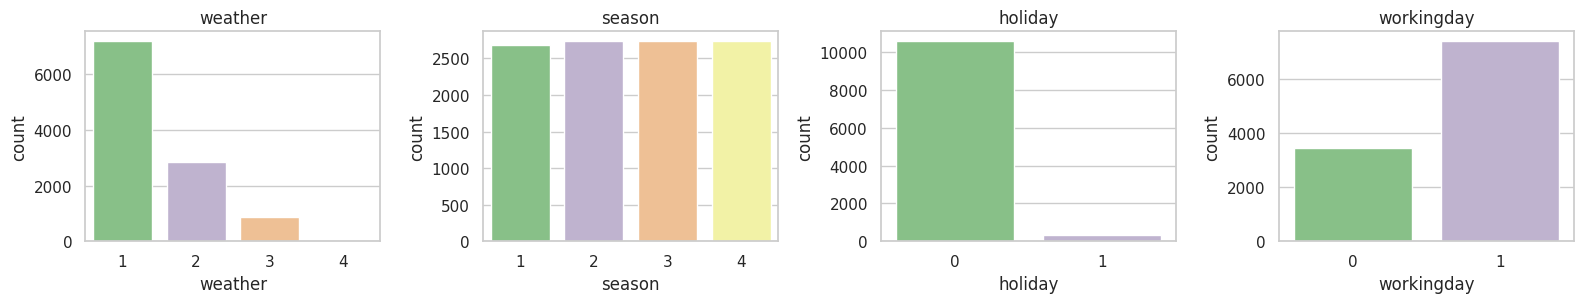

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
sns.countplot(x=df["weather"], hue=df["weather"], palette="Accent", legend=False, ax=axes[0])
sns.countplot(x=df["season"], hue=df["season"], palette="Accent", legend=False, ax=axes[1])
sns.countplot(x=df["holiday"], hue=df["holiday"], palette="Accent", legend=False, ax=axes[2])
sns.countplot(x=df["workingday"], hue=df["workingday"], palette="Accent", legend=False, ax=axes[3])
for ax, title in zip(axes, ["weather", "season", "holiday", "workingday"]):
    ax.set_title(title)
plt.tight_layout()
plt.savefig("figs/01_categorical_counts.png", dpi=110)
plt.show()

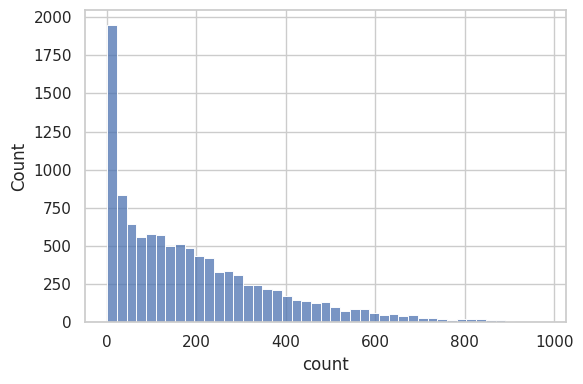

raw skew        : 1.242
log1p(count) skew: -0.851
sqrt(count) skew : 0.258


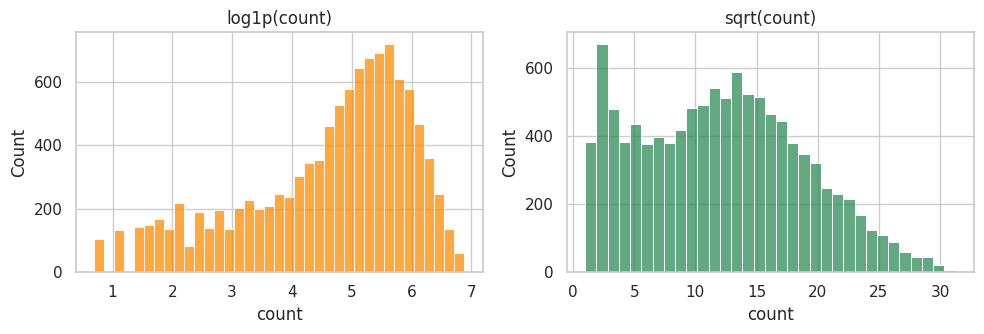

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="count", ax=ax)
plt.tight_layout()
plt.savefig("figs/02_count_histogram.png", dpi=110)
plt.show()

log_count = np.log1p(df["count"])
sqrt_count = np.sqrt(df["count"])
print("raw skew        :", df["count"].skew().round(3))
print("log1p(count) skew:", log_count.skew().round(3))
print("sqrt(count) skew :", sqrt_count.skew().round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.histplot(log_count, ax=axes[0], color="darkorange")
axes[0].set_title("log1p(count)")
sns.histplot(sqrt_count, ax=axes[1], color="seagreen")
axes[1].set_title("sqrt(count)")
plt.tight_layout()
plt.savefig("figs/03_transform_comparison.png", dpi=110)
plt.show()

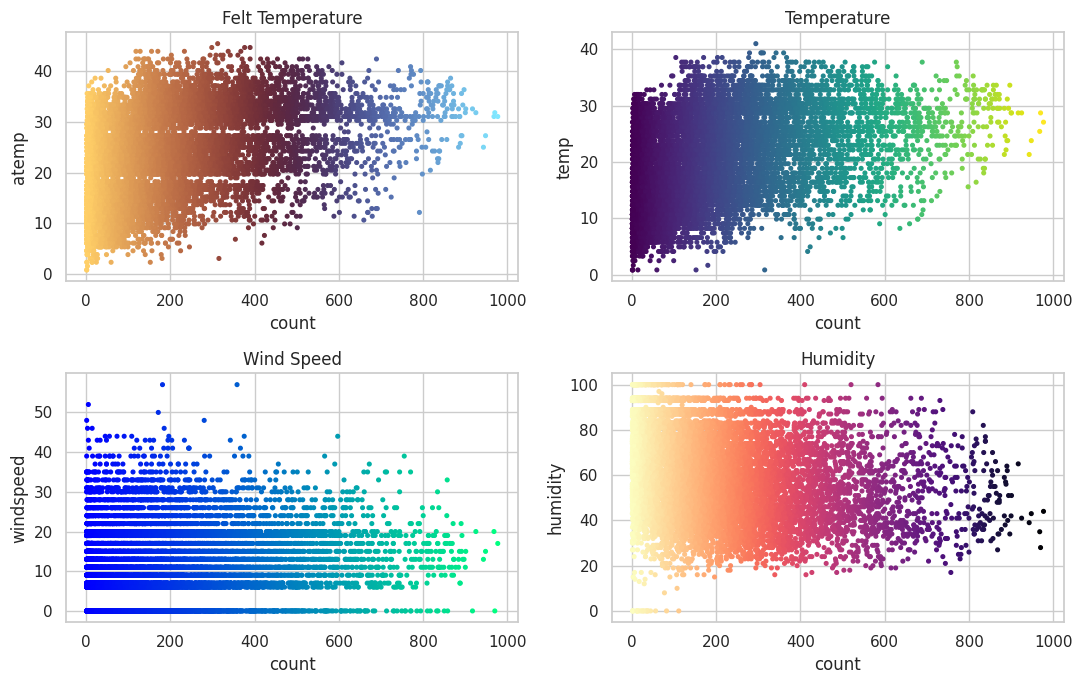

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
scatter_specs = [
    ("atemp", "managua", axes[0, 0], "Felt Temperature"),
    ("temp", "viridis", axes[0, 1], "Temperature"),
    ("windspeed", "winter", axes[1, 0], "Wind Speed"),
    ("humidity", "magma_r", axes[1, 1], "Humidity"),
]
for col, cmap, ax, title in scatter_specs:
    try:
        ax.scatter(df["count"], df[col], marker="o", s=7, c=df["count"], cmap=cmap)
    except ValueError:
        ax.scatter(df["count"], df[col], marker="o", s=7, c=df["count"], cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("count")
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig("figs/04_weather_scatter.png", dpi=110)
plt.show()

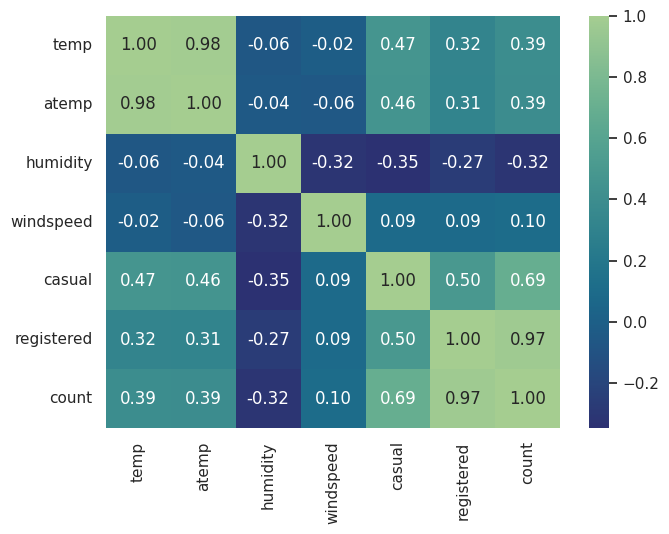

,count
count,1.000000
registered,0.970948
casual,0.690414
temp,0.394454
atemp,0.389784
windspeed,0.101369
humidity,-0.317371


In [38]:
corr_df = df.drop(columns=["datetime", "season", "holiday", "workingday", "weather"])
corr = corr_df.corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="crest_r", ax=ax)
plt.tight_layout()
plt.savefig("figs/05_correlation_heatmap.png", dpi=110)
plt.show()
corr["count"].sort_values(ascending=False)

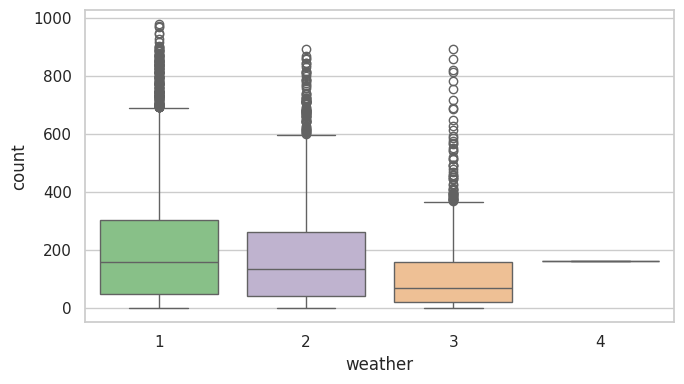

,min,max,count
weather,,,
1,1,977,7192
2,1,890,2834
3,1,891,859
4,164,164,1


In [39]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="weather", y="count", hue="weather", palette="Accent", legend=False, ax=ax)
plt.tight_layout()
plt.savefig("figs/06_weather_boxplot.png", dpi=110)
plt.show()
df.groupby("weather")["count"].agg(["min", "max", "count"])

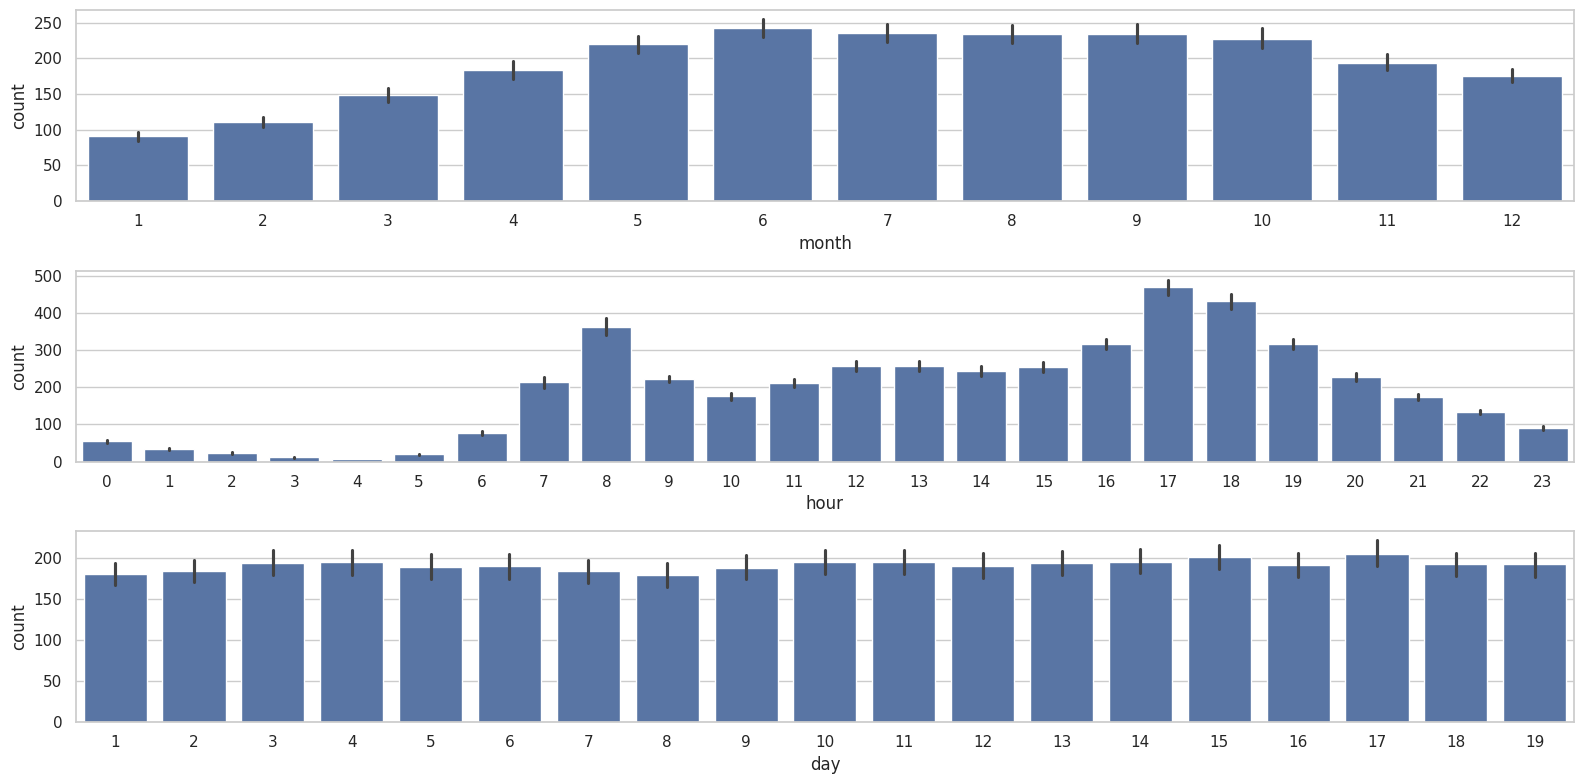

Unique minute values across the whole dataset: [0]


In [40]:
df_time = df.copy()
df_time["datetime"] = pd.to_datetime(df_time["datetime"])
df_time["year"] = df_time["datetime"].dt.year
df_time["month"] = df_time["datetime"].dt.month
df_time["day"] = df_time["datetime"].dt.day
df_time["hour"] = df_time["datetime"].dt.hour
df_time["minute"] = df_time["datetime"].dt.minute

fig, axes = plt.subplots(3, figsize=(16, 8))
sns.barplot(data=df_time, x="month", y="count", ax=axes[0])
sns.barplot(data=df_time, x="hour", y="count", ax=axes[1])
sns.barplot(data=df_time, x="day", y="count", ax=axes[2])
plt.tight_layout()
plt.savefig("figs/07_time_trends.png", dpi=110)
plt.show()

print("Unique minute values across the whole dataset:", df_time["minute"].unique())

## 3. Data Cleaning

In [41]:
print("humidity == 0 rows:", (df["humidity"] == 0).sum())
print("windspeed == 0 rows:", (df["windspeed"] == 0).sum(),
      f"({(df['windspeed'] == 0).mean():.1%} of all rows)")

humidity == 0 rows: 22
windspeed == 0 rows: 1313 (12.1% of all rows)


In [42]:
def clean_humidity(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    mask = frame["humidity"] == 0
    if mask.any():
        group_medians = frame.loc[~mask].groupby(["season", "weather"])["humidity"].median()
        overall_median = frame.loc[~mask, "humidity"].median()
        frame.loc[mask, "humidity"] = frame.loc[mask].apply(
            lambda r: group_medians.get((r["season"], r["weather"]), overall_median), axis=1
        )
    return frame

df_clean = clean_humidity(df)
print("humidity == 0 remaining after cleaning:", (df_clean["humidity"] == 0).sum())

humidity == 0 remaining after cleaning: 0


In [43]:
df_fe = pd.get_dummies(df_clean, columns=["weather", "season"])
df_fe["datetime"] = pd.to_datetime(df_fe["datetime"])
df_fe["year"] = df_fe["datetime"].dt.year
df_fe["month"] = df_fe["datetime"].dt.month
df_fe["day"] = df_fe["datetime"].dt.day
df_fe["hour"] = df_fe["datetime"].dt.hour

drop_cols = ["datetime", "atemp", "casual", "registered", "count"]
FEATURE_COLS = [c for c in df_fe.columns if c not in drop_cols]
NUMERIC_COLS = ["temp", "humidity", "windspeed", "year", "month", "day", "hour"]

print(f"{len(FEATURE_COLS)} model features:")
print(FEATURE_COLS)

17 model features:
['holiday', 'workingday', 'temp', 'humidity', 'windspeed', 'weather_1', 'weather_2', 'weather_3', 'weather_4', 'season_1', 'season_2', 'season_3', 'season_4', 'year', 'month', 'day', 'hour']


## 4. Model Training



In [44]:
X = df_fe[FEATURE_COLS]
y = df_fe["count"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

train: (7620, 17)  val: (1633, 17)  test: (1633, 17)


In [45]:
scaler = StandardScaler()
scaler.fit(X_train[NUMERIC_COLS])

def scale_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame[NUMERIC_COLS] = scaler.transform(frame[NUMERIC_COLS])
    return frame

X_train_scaled = scale_features(X_train)
X_val_scaled = scale_features(X_val)
X_test_scaled = scale_features(X_test)

x_train_t = torch.tensor(X_train_scaled.to_numpy(dtype=np.float32), dtype=torch.float32)
x_val_t = torch.tensor(X_val_scaled.to_numpy(dtype=np.float32), dtype=torch.float32)
x_test_t = torch.tensor(X_test_scaled.to_numpy(dtype=np.float32), dtype=torch.float32)

y_train_t = torch.tensor(np.log1p(y_train.to_numpy()), dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(np.log1p(y_val.to_numpy()), dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(np.log1p(y_test.to_numpy()), dtype=torch.float32).view(-1, 1)

n_features = x_train_t.shape[1]
print("n_features:", n_features)

n_features: 17


In [46]:
class BikeData(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]

train_dataset = BikeData(x_train_t, y_train_t)
val_dataset = BikeData(x_val_t, y_val_t)
test_dataset = BikeData(x_test_t, y_test_t)

### Model


In [47]:
class BikeNN(nn.Module):
    def __init__(self, n, hidden_sizes=(64, 32, 16)):
        super().__init__()
        layers = []
        prev = n
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [48]:
criterion = nn.MSELoss()

def epochOne(model, loader, optimizer):
    model.train()
    running_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x_batch.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * x_batch.size(0)
    return running_loss / len(loader.dataset)

def evaluate_real(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu())
            actuals.append(y_batch.cpu())
    preds = torch.expm1(torch.cat(preds)).numpy().flatten()
    actuals = torch.expm1(torch.cat(actuals)).numpy().flatten()
    preds = np.clip(preds, 0, None)

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return rmse, mae, r2

In [49]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

### Hyperparameter tuning with Optuna

In [50]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    hidden_sizes = trial.suggest_categorical("hidden_sizes", [(64, 32, 16), (128, 64, 32), (32, 16, 8)])

    train_loader_ = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_ = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    trial_model = BikeNN(n_features, hidden_sizes).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)
    early_stopper = EarlyStopping(patience=8)

    for epoch in range(100):
        epochOne(trial_model, train_loader_, optimizer)
        val_loss = evaluate(trial_model, val_loader_)
        early_stopper(val_loss, trial_model)
        if early_stopper.early_stop:
            break

    return early_stopper.best_loss

In [51]:
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
t0 = time.time()
study.optimize(objective, n_trials=20)
print(f"Optuna search finished in {time.time()-t0:.0f}s")
print("Best validation loss:", round(study.best_value, 4))
print("Best params:", study.best_params)

Optuna search finished in 414s
Best validation loss: 0.1123
Best params: {'lr': 0.0015184951111410269, 'weight_decay': 0.00014046853939215378, 'batch_size': 32, 'hidden_sizes': (64, 32, 16)}


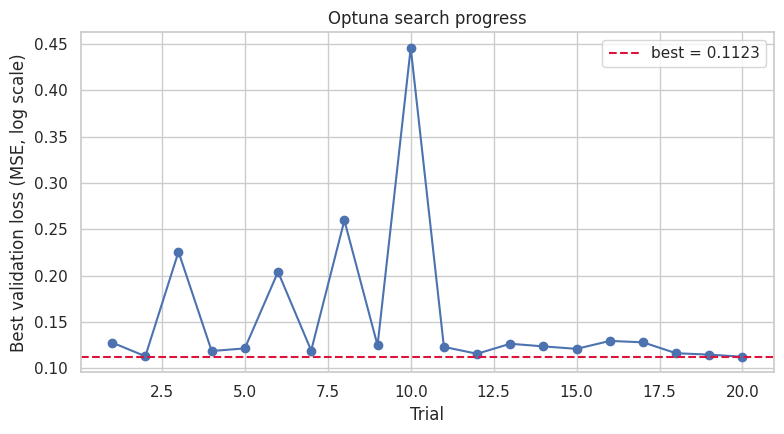

In [52]:
fig, ax = plt.subplots(figsize=(8, 4.5))
trial_vals = [t.value for t in study.trials if t.value is not None]
ax.plot(range(1, len(trial_vals) + 1), trial_vals, marker="o")
ax.axhline(study.best_value, color="crimson", ls="--", label=f"best = {study.best_value:.4f}")
ax.set_xlabel("Trial")
ax.set_ylabel("Best validation loss (MSE, log scale)")
ax.set_title("Optuna search progress")
ax.legend()
plt.tight_layout()
plt.savefig("figs/08_optuna_trials.png", dpi=110)
plt.show()

## 8. Validation & Testing — final training run

In [53]:
best = study.best_params
final_model = BikeNN(n_features, best["hidden_sizes"]).to(device)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])

train_loader_final = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)
val_loader_final = DataLoader(val_dataset, batch_size=best["batch_size"], shuffle=False)

history = {"train_loss": [], "val_loss": []}
epochs = 100
total_start = time.time()
early_stopper = EarlyStopping(patience=12)

for epoch in range(epochs):
    start = time.time()
    train_loss = epochOne(final_model, train_loader_final, final_optimizer)
    val_loss = evaluate(final_model, val_loader_final)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | "
          f"Validation Loss: {val_loss:.4f} | {time.time()-start:.1f} sec")

    early_stopper(val_loss, final_model)
    if early_stopper.early_stop:
        print(f"\nStopping at epoch: {epoch+1} | Best val loss: {early_stopper.best_loss:.4f}")
        break

early_stopper.restore_best(final_model)
print(f"Total training time: {time.time()-total_start:.0f}s")

Epoch 1/100 | Train Loss: 3.4296 | Validation Loss: 1.0933 | 0.5 sec
Epoch 2/100 | Train Loss: 1.0016 | Validation Loss: 0.8677 | 0.5 sec
Epoch 3/100 | Train Loss: 0.8003 | Validation Loss: 0.6991 | 0.5 sec
Epoch 4/100 | Train Loss: 0.6175 | Validation Loss: 0.4753 | 0.5 sec
Epoch 5/100 | Train Loss: 0.3651 | Validation Loss: 0.2789 | 0.5 sec
Epoch 6/100 | Train Loss: 0.2395 | Validation Loss: 0.2209 | 0.6 sec
Epoch 7/100 | Train Loss: 0.2114 | Validation Loss: 0.1965 | 0.5 sec
Epoch 8/100 | Train Loss: 0.1997 | Validation Loss: 0.1942 | 0.5 sec
Epoch 9/100 | Train Loss: 0.1951 | Validation Loss: 0.1993 | 0.5 sec
Epoch 10/100 | Train Loss: 0.1924 | Validation Loss: 0.2115 | 0.6 sec
Epoch 11/100 | Train Loss: 0.1871 | Validation Loss: 0.1892 | 0.6 sec
Epoch 12/100 | Train Loss: 0.1794 | Validation Loss: 0.1935 | 0.6 sec
Epoch 13/100 | Train Loss: 0.1734 | Validation Loss: 0.1754 | 0.7 sec
Epoch 14/100 | Train Loss: 0.1642 | Validation Loss: 0.1705 | 0.6 sec
Epoch 15/100 | Train Loss: 0.

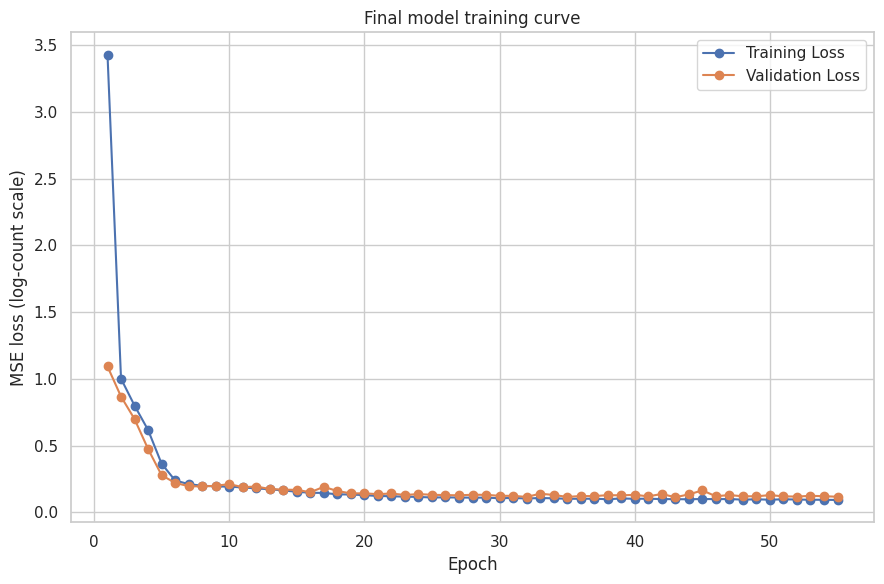

In [54]:
epochs_range = list(range(1, len(history["train_loss"]) + 1))
plt.figure(figsize=(9, 6))
plt.plot(epochs_range, history["train_loss"], label="Training Loss", marker="o")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (log-count scale)")
plt.title("Final model training curve")
plt.legend()
plt.tight_layout()
plt.savefig("figs/09_training_curve.png", dpi=110)
plt.show()

### Final, one-time evaluation on the untouched test set

In [55]:
test_loader_final = DataLoader(test_dataset, batch_size=64, shuffle=False)
rmse, mae, r2 = evaluate_real(final_model, test_loader_final)
print("Held-out TEST metrics (original count scale, never seen during tuning):")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE : {mae:.2f}")
print(f"  R2  : {r2:.3f}")

Held-out TEST metrics (original count scale, never seen during tuning):
  RMSE: 56.92
  MAE : 35.14
  R2  : 0.902


## 9. Experimentation & Comparison

In [56]:
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

comparison_df = pd.DataFrame([
    {"model": "Mean baseline", "RMSE": baseline_rmse, "MAE": baseline_mae, "R2": baseline_r2},
    {"model": "Neural Network (tuned)", "RMSE": rmse, "MAE": mae, "R2": r2},
]).sort_values("RMSE")
comparison_df

,model,RMSE,MAE,R2
1,Neural Network (tuned),56.922074,35.138012,0.902067
0,Mean baseline,181.896280,142.228272,-0.000033


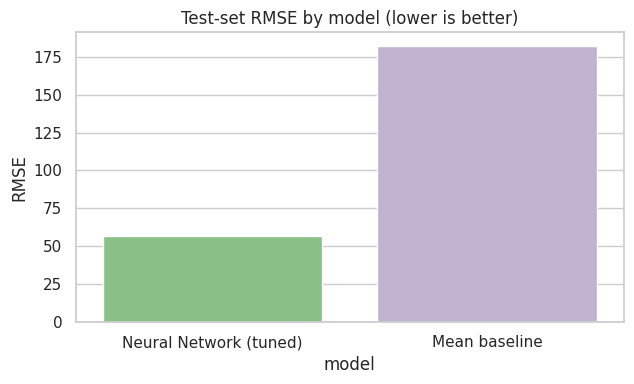

In [57]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(data=comparison_df, x="model", y="RMSE", hue="model", palette="Accent", legend=False, ax=ax)
ax.set_title("Test-set RMSE by model (lower is better)")
plt.tight_layout()
plt.savefig("figs/10_model_comparison.png", dpi=110)
plt.show()

## 10. Model Saving

In [58]:
os.makedirs("model", exist_ok=True)
torch.save({
    "model_state_dict": final_model.state_dict(),
    "hidden_sizes": best["hidden_sizes"],
    "n_features": n_features,
    "feature_names": FEATURE_COLS,
    "numeric_cols": NUMERIC_COLS,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
}, "model/bike_model.pt")

with open("model/metrics.json", "w") as f:
    json.dump({
        "test_metrics": {"RMSE": float(rmse), "MAE": float(mae), "R2": float(r2)},
        "baseline_metrics": {"RMSE": float(baseline_rmse), "MAE": float(baseline_mae), "R2": float(baseline_r2)},
        "best_hyperparams": {**best, "hidden_sizes": list(best["hidden_sizes"])},
        "epochs_trained": len(history["train_loss"]),
    }, f, indent=2)

print("Saved model/bike_model.pt and model/metrics.json")

Saved model/bike_model.pt and model/metrics.json


## Summary

In [59]:
print(comparison_df.to_string(index=False))

                 model       RMSE        MAE        R2
Neural Network (tuned)  56.922074  35.138012  0.902067
         Mean baseline 181.896280 142.228272 -0.000033
